In [ ]:
!pip install timm --quiet
import timm
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.optim as optim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.0 MB/s eta 0:00:00


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryashah2k/mango-leaf-disease-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/mango-leaf-disease-dataset


In [ ]:
from torchvision.transforms.functional import resize, pad

class AspectPadTo224:
    def __call__(self, img):
        img = resize(img, 224)
        w, h = img.size
        pad_left = (224 - w) // 2
        pad_right = 224 - w - pad_left
        pad_top = (224 - h) // 2
        pad_bottom = 224 - h - pad_top
        return pad(img, (pad_left, pad_top, pad_right, pad_bottom))

transform = transforms.Compose([
    AspectPadTo224(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
from torchvision.datasets import ImageFolder # Import ImageFolder

dataset = ImageFolder('/kaggle/input/mango-leaf-disease-dataset', transform=transform) # Now ImageFolder is accessible
class_names = dataset.classes

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, len(class_names))
model = model.to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        acc = correct / len(train_loader.dataset)
        print(f"Epoch {epoch+1}, Loss: {total_loss:.3f}, Train Acc: {acc:.4f}")

        validate(model, val_loader)

def validate(model, val_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(1).cpu()
            all_preds.extend(preds)
            all_labels.extend(labels)

    cm = confusion_matrix(all_labels, all_preds)
    print(classification_report(all_labels, all_preds, target_names=class_names))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Epoch 1, Loss: 17.660, Train Acc: 0.9397
                  precision    recall  f1-score   support

     Anthracnose       0.99      1.00      1.00       101
Bacterial Canker       0.99      1.00      1.00       102
  Cutting Weevil       1.00      0.99      0.99        83
        Die Back       1.00      1.00      1.00       105
      Gall Midge       1.00      0.99      1.00       114
         Healthy       1.00      0.98      0.99        88
  Powdery Mildew       1.00      0.87      0.93       102
     Sooty Mould       0.88      1.00      0.93       105

        accuracy                           0.98       800
       macro avg       0.98      0.98      0.98       800
    weighted avg       0.98      0.98      0.98       800



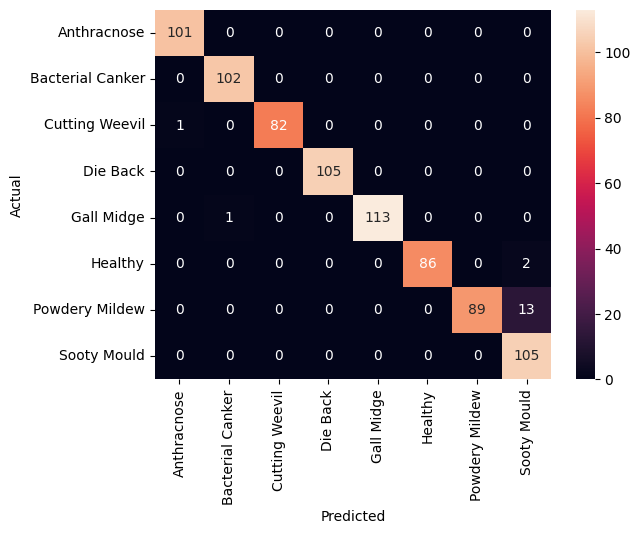

Epoch 2, Loss: 2.568, Train Acc: 0.9938
                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00       101
Bacterial Canker       1.00      1.00      1.00       102
  Cutting Weevil       1.00      1.00      1.00        83
        Die Back       1.00      1.00      1.00       105
      Gall Midge       1.00      1.00      1.00       114
         Healthy       1.00      1.00      1.00        88
  Powdery Mildew       1.00      1.00      1.00       102
     Sooty Mould       1.00      1.00      1.00       105

        accuracy                           1.00       800
       macro avg       1.00      1.00      1.00       800
    weighted avg       1.00      1.00      1.00       800



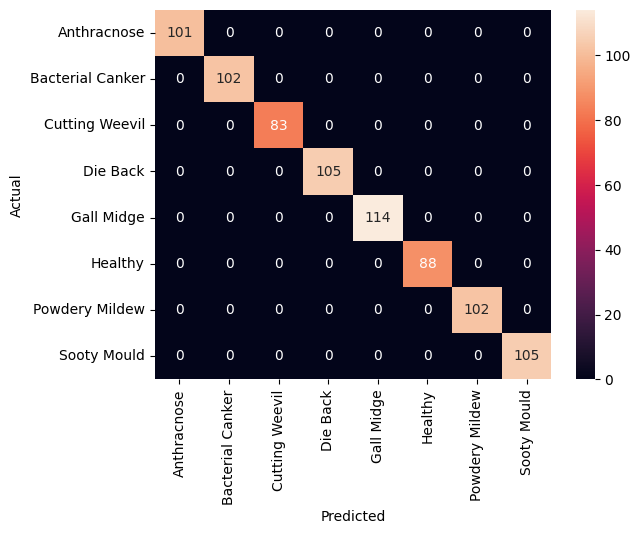

Epoch 3, Loss: 3.075, Train Acc: 0.9916
                  precision    recall  f1-score   support

     Anthracnose       1.00      0.79      0.88       101
Bacterial Canker       1.00      0.91      0.95       102
  Cutting Weevil       1.00      1.00      1.00        83
        Die Back       0.94      1.00      0.97       105
      Gall Midge       0.80      0.99      0.88       114
         Healthy       1.00      0.97      0.98        88
  Powdery Mildew       0.98      1.00      0.99       102
     Sooty Mould       1.00      0.96      0.98       105

        accuracy                           0.95       800
       macro avg       0.96      0.95      0.96       800
    weighted avg       0.96      0.95      0.95       800



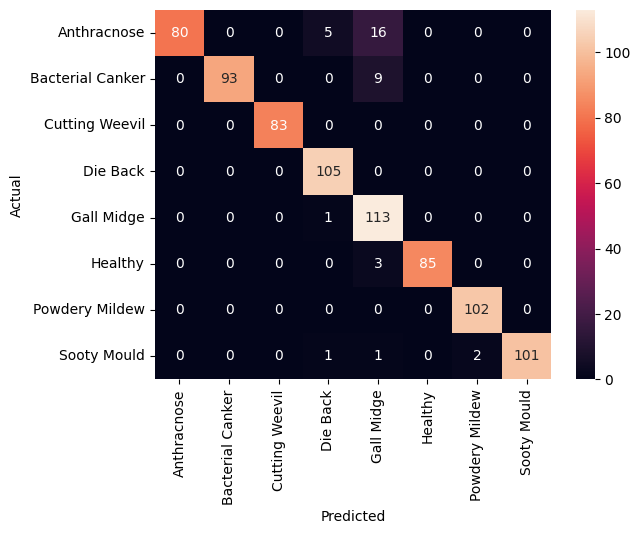

Epoch 4, Loss: 2.200, Train Acc: 0.9928
                  precision    recall  f1-score   support

     Anthracnose       1.00      0.98      0.99       101
Bacterial Canker       1.00      1.00      1.00       102
  Cutting Weevil       1.00      1.00      1.00        83
        Die Back       0.99      1.00      1.00       105
      Gall Midge       0.99      0.99      0.99       114
         Healthy       1.00      1.00      1.00        88
  Powdery Mildew       0.98      1.00      0.99       102
     Sooty Mould       1.00      0.99      1.00       105

        accuracy                           0.99       800
       macro avg       1.00      1.00      1.00       800
    weighted avg       1.00      0.99      0.99       800



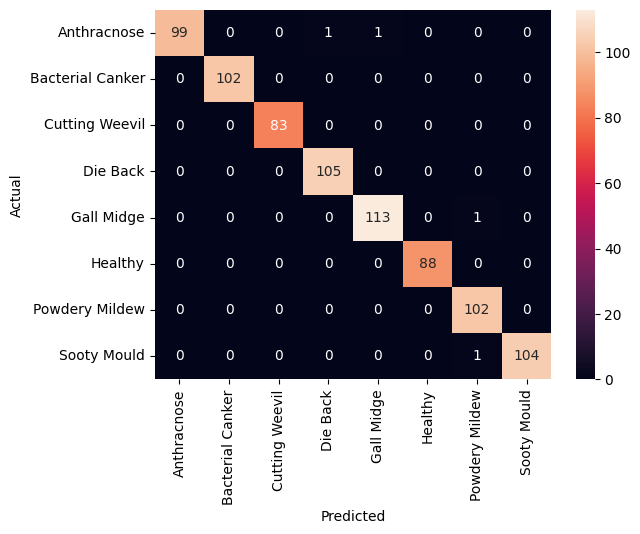

Epoch 5, Loss: 4.281, Train Acc: 0.9903
                  precision    recall  f1-score   support

     Anthracnose       0.99      1.00      1.00       101
Bacterial Canker       1.00      0.97      0.99       102
  Cutting Weevil       1.00      1.00      1.00        83
        Die Back       1.00      0.99      1.00       105
      Gall Midge       0.89      1.00      0.94       114
         Healthy       1.00      0.97      0.98        88
  Powdery Mildew       0.97      0.97      0.97       102
     Sooty Mould       0.99      0.91      0.95       105

        accuracy                           0.98       800
       macro avg       0.98      0.98      0.98       800
    weighted avg       0.98      0.98      0.98       800



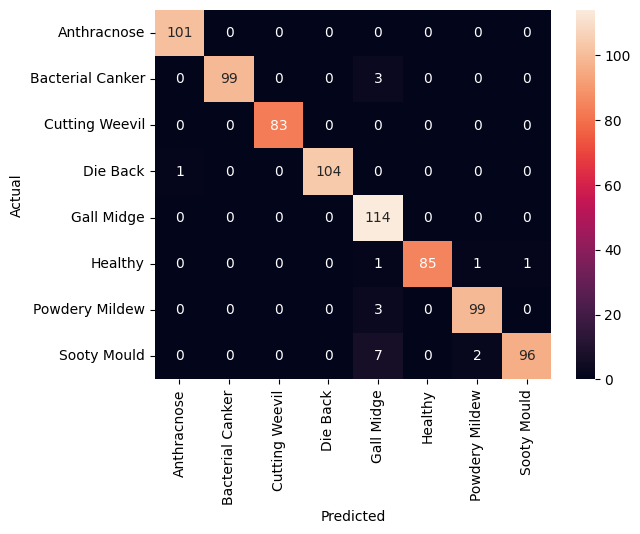

In [ ]:
train(model, train_loader, val_loader)


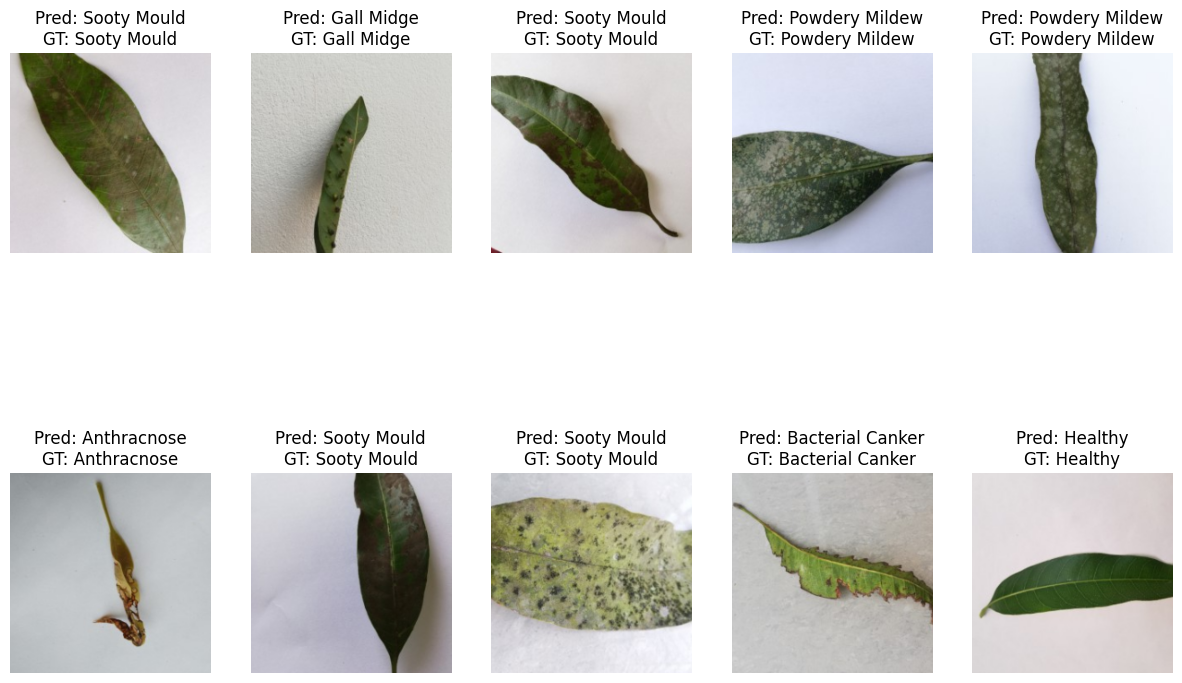

In [ ]:
def show_predictions(model, val_loader, num_images=10):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(15, 10))
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images.to(device))
            preds = outputs.argmax(1).cpu()
            for i in range(len(images)):
                if images_shown >= num_images:
                    return
                img = images[i].permute(1, 2, 0) * 0.5 + 0.5  # Unnormalize
                plt.subplot(2, 5, images_shown + 1)
                plt.imshow(img)
                plt.title(f"Pred: {class_names[preds[i]]}\nGT: {class_names[labels[i]]}")
                plt.axis('off')
                images_shown += 1

show_predictions(model, val_loader)


In [ ]:
import torch
import matplotlib.pyplot as plt

def visualize_attention_vit(model, image_tensor):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)  # Add batch dimension

    attn_maps = []

    def hook_fn(module, input, output):
        # Capture the attention weights (second element of the output tuple)
        attn_maps.append(output[1].detach().cpu())  # Attention is in output[1] (the second output)

    # Register the hook to the first block's attention layer (self-attention)
    hook_handle = model.blocks[0].attn.register_forward_hook(hook_fn)

    # Run the forward pass to extract attention weights
    with torch.no_grad():
        _ = model(image_tensor)  # Perform forward pass

    # Remove the hook after the forward pass
    hook_handle.remove()

    # Extract the attention weights from the first attention block
    attn = attn_maps[0]  # Shape: [Batch, num_heads, seq_len, seq_len]

    # We average the attention across heads (ignoring the CLS token)
    avg_attn = attn.mean(dim=1)[0, 1:].reshape(14, 14)  # [1, 14, 14] excluding CLS token
    attn_map = avg_attn.cpu()

    # Plot the attention map
    plt.imshow(attn_map, cmap='viridis')
    plt.title("ViT Attention Map (Layer 0, avg heads)")
    plt.axis('off')
    plt.colorbar()
    plt.show()

In [ ]:
# Take one image from the validation set
sample_image, _ = val_dataset[0]
visualize_attention_vit(model, sample_image)

In [ ]:
# Save the entire model
def save_entire_model(model, path):
    # Remove the hook_fn if exists to make model picklable
    for block in model.blocks:
        if hasattr(block.attn, '_forward_hooks'):
            block.attn._forward_hooks.clear()

    torch.save(model, path)
    print(f"Entire model saved at {path}")

# Example usage:
save_entire_model(model, 'vit_mango_leaf_full.pth')

# # Load the entire model
# def load_entire_model(path):
#     model = torch.load(path)
#     model.eval()  # Set the model to evaluation mode
#     print(f"Entire model loaded from {path}")
#     return model

# # Example usage:
# model = load_entire_model('vit_mango_leaf_full.pth')


Entire model saved at vit_mango_leaf_full.pth
